In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [135]:
Contacts_clean = pd.read_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Contakts_cleaned.xlsx')
Calls_clean = pd.read_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Calls_cleaned.xlsx')
Deals_clean = pd.read_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Deals_cleaned.xlsx')
Spend_clean = pd.read_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Spend_cleaned.xlsx')

Descriptive statistics:
1. Calculate summary statistics (mean, median, mode, range) for numerical fields.
2. Analyze categorical fields such as quality, stage, source, and product.

In [136]:
# Для числовых колонок: среднее, медиана, мода, диапазон
import pandas as pd
from scipy import stats

def numeric_summary(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    summary = pd.DataFrame({
        'mean': df[numeric_cols].mean(),
        'median': df[numeric_cols].median(),
        'mode': df[numeric_cols].mode().iloc[0],
        'min': df[numeric_cols].min(),
        'max': df[numeric_cols].max(),
    })
    summary['range'] = summary['max'] - summary['min']
    return summary.round(2)

# Пример для всех 4 датасетов
print("Deals_clean:")
display(numeric_summary(Deals_clean))

print("\nCalls_clean:")
display(numeric_summary(Calls_clean))

print("\nContacts_clean:")
display(numeric_summary(Contacts_clean))

print("\nSpend_clean:")
display(numeric_summary(Spend_clean))


Deals_clean:


,mean,median,mode,min,max,range
Unnamed: 0,1.078119e+04,1.075300e+04,0.000000e+00,0.000000e+00,2.159200e+04,21592.0
Id,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,55971840.0
Quality,1.860000e+00,2.000000e+00,2.000000e+00,0.000000e+00,5.000000e+00,5.0
SLA,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
Course duration,1.690000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,11.0
Months of study,2.100000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,11.0
Initial Amount Paid,1.832200e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.150000e+04,11500.0
Offer Total Amount,1.380090e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.150000e+04,11500.0
Contact Name,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,56019968.0



Calls_clean:


,mean,median,mode,min,max,range
Id,5.805028e+18,-3.418344e+18,5.805028e+18,5.805028e+18,5.805028e+18,56147968.0
CONTACTID,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,5.805028e+18,56247296.0
Call Duration (in seconds),1.745900e+02,9.000000e+00,0.000000e+00,0.000000e+00,7.625000e+03,7625.0
Scheduled in CRM,-1.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,1.000000e+00,2.0



Contacts_clean:


,mean,median,mode,min,max,range
Unnamed: 0,9.273500e+03,9.273500e+03,0,0,18547,18547
Id,5.805028e+18,-3.418344e+18,5805028000000645014,5805028000000645014,5805028000056907001,56261987



Spend_clean:


,mean,median,mode,min,max,range
Impressions,2674.12,89.00,0.0,0.0,431445.0,431445.0
Spend,7.08,0.89,0.0,0.0,774.0,774.0
Clicks,24.75,2.00,0.0,0.0,2415.0,2415.0


In [137]:
#Топ 10 в каждой категории
def categorical_summary(df):
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        print(f"\n🔹 {col}")
        print(df[col].value_counts(dropna=False).head(10))  #топ-10 значений

# Применяем
print("Deals_clean:")
categorical_summary(Deals_clean)

print("\nCalls_clean:")
categorical_summary(Calls_clean)

print("\nContacts_clean:")
categorical_summary(Contacts_clean)

print("\nSpend_clean:")
categorical_summary(Spend_clean)


Deals_clean:

🔹 Deal Owner Name
Deal Owner Name
Charlie Davis      2945
Julia Nelson       2239
Ulysses Adams      2163
Quincy Vincent     1877
Paula Underwood    1856
Ben Hall           1345
Nina Scott         1281
Victor Barnes      1224
Cara Iverson       1056
Diana Evans        1009
Name: count, dtype: int64

🔹 Stage
Stage
Lost                         13937
Payment Done                  3241
Registered on Webinar         2066
Call Delayed                  1901
Qualificated                   112
Registered on Offline Day       99
Need to Call - Sales            33
Need To Call                    31
Need a consultation             23
Test Sent                       19
Name: count, dtype: int64

🔹 Lost Reason
Lost Reason
NaN                            5448
Doesn't Answer                 4124
Changed Decision               2131
Non target                     1754
Duplicate                      1743
Stopped Answering              1582
Invalid number                 1473
needs time to th

Time series analysis:

1. Analyze the trend of deal creation over time and its relationship with calls.
2. Examine the distribution of deal closing times and the duration from creation to closing.


/tmp/ipykernel_1609/2099320416.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Deals_clean.groupby(pd.Grouper(key='Created Time', freq='M'))


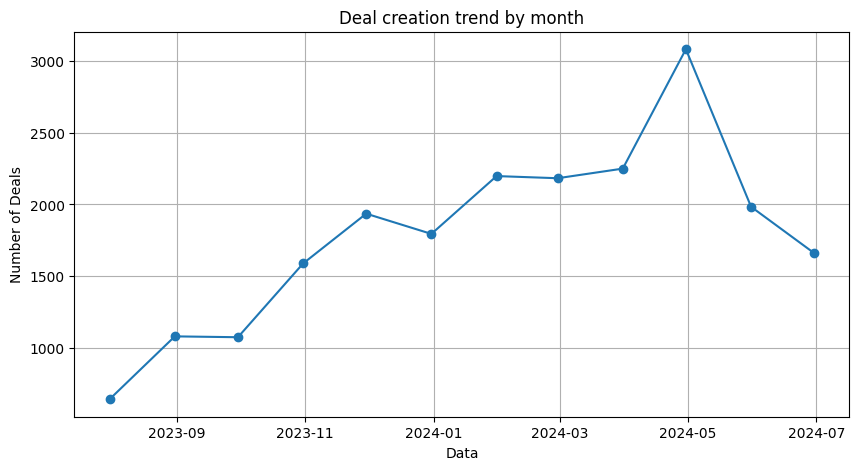

In [138]:
# Тенденция создания сделок по месяцам

# Группировка по месяцам
deals_over_time = (
    Deals_clean.groupby(pd.Grouper(key='Created Time', freq='M'))
    .size()
    .reset_index(name='Count')
)

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(deals_over_time['Created Time'], deals_over_time['Count'], marker='o')
plt.title('Deal creation trend by month')
plt.xlabel('Data')
plt.ylabel('Number of Deals')
plt.grid(True)
plt.show()


создание сделок демонстрирует выраженную сезонную динамику, в месяцы новогодних праздников, летних каникул и отпусков заметно спад и заметный рост перед ними

/tmp/ipykernel_1609/3868646875.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Deals_clean.groupby(pd.Grouper(key='Created Time', freq='M'))
/tmp/ipykernel_1609/3868646875.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Calls_clean.groupby(pd.Grouper(key='Call Start Time', freq='M'))


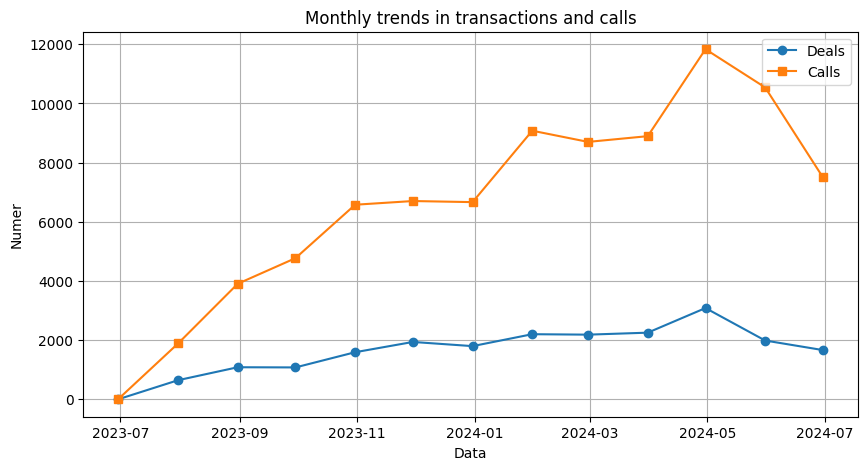

In [139]:
#Динамика сделок и звонков по месяцам

# Группировка по месяцам
deals_over_time = (
    Deals_clean.groupby(pd.Grouper(key='Created Time', freq='M'))
    .size()
    .reset_index(name='Deals')
)

calls_over_time = (
    Calls_clean.groupby(pd.Grouper(key='Call Start Time', freq='M'))
    .size()
    .reset_index(name='Calls')
)

# Переименовываем колонки даты в единый формат
deals_over_time.rename(columns={'Created Time': 'Date'}, inplace=True)
calls_over_time.rename(columns={'Call Start Time': 'Date'}, inplace=True)

# Объединяем два датафрейма по дате
merged_trend = pd.merge(deals_over_time, calls_over_time, on='Date', how='outer').fillna(0)

# Сортируем по дате
merged_trend = merged_trend.sort_values(by='Date')

# Визуализация
plt.figure(figsize=(10,5))
plt.plot(merged_trend['Date'], merged_trend['Deals'], label='Deals', marker='o')
plt.plot(merged_trend['Date'], merged_trend['Calls'], label='Calls', marker='s')
plt.title('Monthly trends in transactions and calls')
plt.xlabel('Data')
plt.ylabel('Numer')
plt.legend()
plt.grid(True)
plt.show()



The chart shows that calls follow the same trend, which is logical and confirms the relationship between call activity intensity and the number of transactions created.

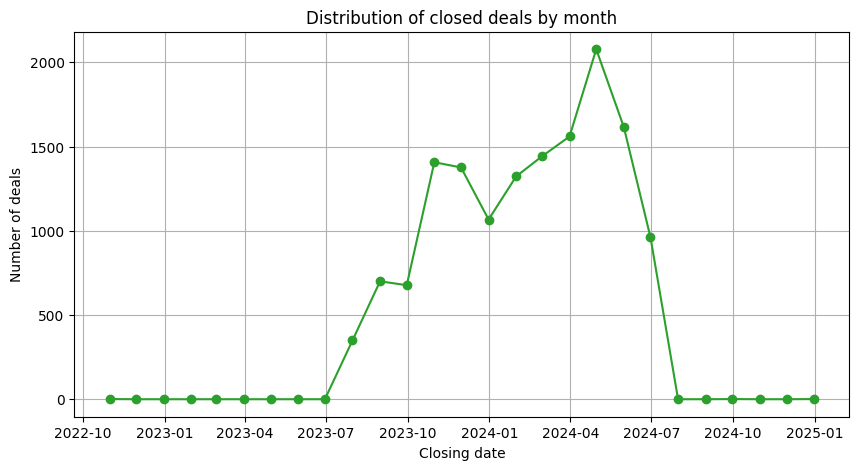

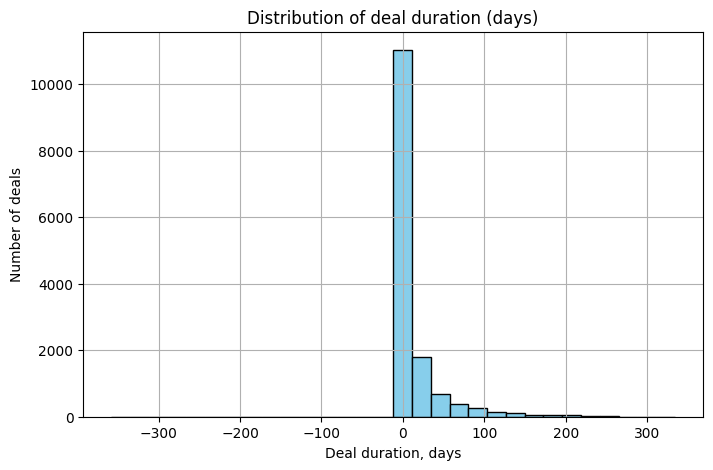

Deal duration statistics:
count    14559.000000
mean        13.859194
std         31.689399
min       -358.000000
25%          0.000000
50%          2.000000
75%         11.000000
max        334.000000
Name: Deal Duration (days), dtype: float64


In [140]:
# Распределение закрытых сделок по месяцам и длительность в днях

#  Рассчитаем длительность сделки
Deals_clean['Deal Duration (days)'] = (Deals_clean['Closing Date'] - Deals_clean['Created Time']).dt.days

# Посмотрим распределение по месяцам закрытия
deals_closed_over_time = (
    Deals_clean.groupby(pd.Grouper(key='Closing Date', freq='ME'))
    .size()
    .reset_index(name='Closed Deals')
)

# Визуализация — количество закрытых сделок по месяцам
plt.figure(figsize=(10,5))
plt.plot(deals_closed_over_time['Closing Date'], deals_closed_over_time['Closed Deals'], marker='o', color='tab:green')
plt.title('Distribution of closed deals by month')
plt.xlabel('Closing date')
plt.ylabel('Number of deals')
plt.grid(True)
plt.show()


# Распределение длительности сделок (в днях)
plt.figure(figsize=(8,5))
Deals_clean['Deal Duration (days)'].dropna().plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of deal duration (days)')
plt.xlabel('Deal duration, days')
plt.ylabel('Number of deals')
plt.grid(True)
plt.show()

# Описательная статистика по длительности
duration_stats = Deals_clean['Deal Duration (days)'].describe(percentiles=[0.25, 0.5, 0.75])
print('Deal duration statistics:')
print(duration_stats)


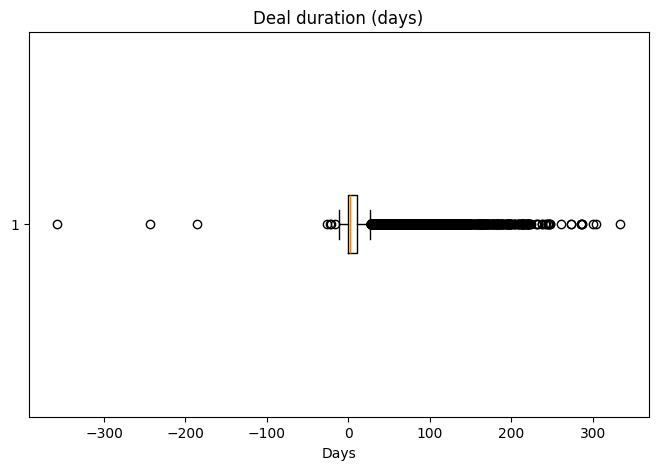

In [141]:
# Построим boxplot для Deal Duration
plt.figure(figsize=(8,5))
plt.boxplot(Deals_clean['Deal Duration (days)'].dropna(), vert=False)
plt.title('Deal duration (days)')
plt.xlabel('Days')
plt.show()

In [142]:
Q1 = Deals_clean['Deal Duration (days)'].quantile(0.25)
Q3 = Deals_clean['Deal Duration (days)'].quantile(0.75)
IQR = Q3 - Q1


Deals_no_outliers = Deals_clean[
    (Deals_clean['Deal Duration (days)'] >= Q1 - 1.5*IQR) &
    (Deals_clean['Deal Duration (days)'] <= Q3 + 1.5*IQR)
]

# Новая статистика
print(Deals_no_outliers['Deal Duration (days)'].describe())


count    12504.000000
mean         3.789507
std          6.159819
min        -12.000000
25%         -1.000000
50%          1.000000
75%          6.000000
max         27.000000
Name: Deal Duration (days), dtype: float64


Negative values in **Deal Duration (days)** indicate that the deal closing date is earlier than the deal creation date. Logically, this is impossible. Possible reasons: - Data entry errors - Different time zones Therefore, it is best to exclude these records from the statistical analysis.

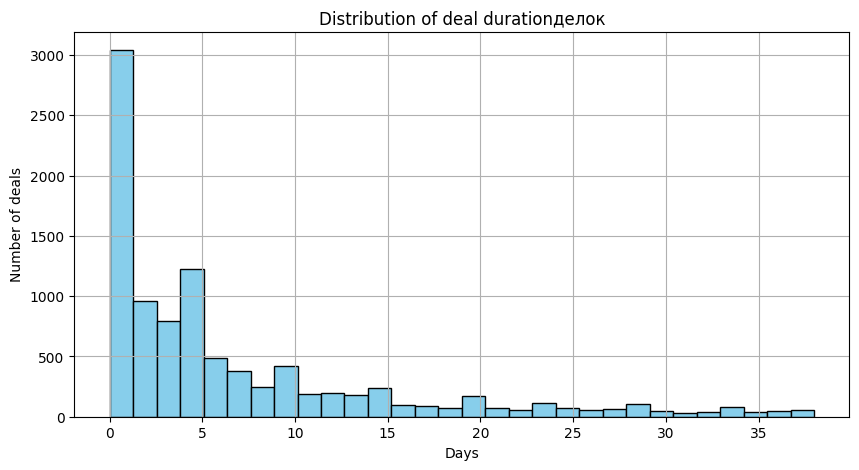

In [143]:
# Создаем копию и убираем отрицательные значения
deals_cleaned = Deals_clean[Deals_clean['Deal Duration (days)'] >= 0]

# Вычислим границы "усов" (IQR) для удаления выбросов
Q1 = deals_cleaned['Deal Duration (days)'].quantile(0.25)
Q3 = deals_cleaned['Deal Duration (days)'].quantile(0.75)
IQR = Q3 - Q1

# Фильтруем значения без выбросов
deals_no_outliers = deals_cleaned[
    (deals_cleaned['Deal Duration (days)'] >= Q1 - 1.5*IQR) &
    (deals_cleaned['Deal Duration (days)'] <= Q3 + 1.5*IQR)
]


# Гистограмма распределения
plt.figure(figsize=(10,5))
plt.hist(deals_no_outliers['Deal Duration (days)'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of deal durationделок')
plt.xlabel('Days')
plt.ylabel('Number of deals')
plt.grid(True)
plt.show()



Conclusions on the distribution of deal closing time and the duration from creation to closure:

- The average deal duration after removing negative values and outliers is approximately 3–4 days, indicating that most deals are closed fairly quickly.
- The median duration is about 1 day, which confirms that the majority of deals are closed within 1–2 days.
- The range of deal durations before cleaning was very wide (from -358 to 334 days), indicating data errors and rare extremely long deals. After cleaning, the range became more realistic: from 0 to 27 days.
- Outliers and negative values: negative day values meant that the deal closing date was earlier than the creation date, which is not possible in reality — such records should be checked or excluded.
- Distribution: most deals are closed very quickly (1–2 days), a small portion within a week, and a very small share takes more than two weeks. The plots (boxplot and histogram) show a strongly right-skewed distribution with a long right tail.

- Practical implication: the analysis shows that for most campaigns the sales process is quite fast. Outliers and rare long deals may indicate process issues or data errors that should be investigated separately.

-

Campaign performance analysis:
 1. Compare the effectiveness of different campaigns in terms of lead generation and conversion rate.
 2. Evaluate the effectiveness of different marketing sources (Source) in generating high-quality leads

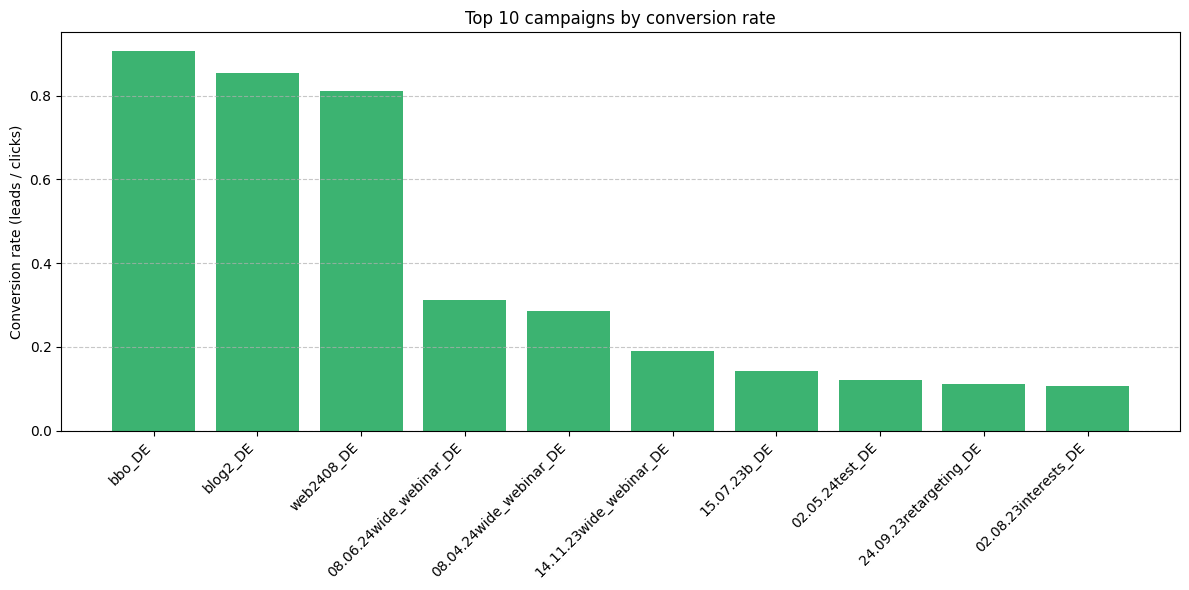

,Campaign,Leads,Clicks,Conversion_rate
75,bbo_DE,116,128.0,0.906250
78,blog2_DE,213,249.0,0.855422
139,web2408_DE,125,154.0,0.811688
10,08.06.24wide_webinar_DE,99,318.0,0.311321
9,08.04.24wide_webinar_DE,236,826.0,0.285714
20,14.11.23wide_webinar_DE,76,401.0,0.189526
24,15.07.23b_DE,126,881.0,0.143019
1,02.05.24test_DE,96,790.0,0.121519
40,24.09.23retargeting_DE,460,4143.0,0.111031
3,02.08.23interests_DE,8,76.0,0.105263


In [144]:
# Количество уникальных лидов (контактов) по кампаниям
leads_per_campaign = (
    Deals_clean.groupby('Campaign')['Contact Name']
    .nunique()  # уникальные контакты, а не количество строк
    .reset_index(name='Leads')
)

# Суммарные клики по кампаниям
clicks_per_campaign = (
    Spend_clean.groupby('Campaign')['Clicks']
    .sum()
    .reset_index(name='Clicks')
)

# Объединяем данные
campaign_performance = pd.merge(leads_per_campaign, clicks_per_campaign, on='Campaign', how='left')

# Рассчитываем конверсию
campaign_performance['Conversion_rate'] = campaign_performance['Leads'] / campaign_performance['Clicks']

# Сортируем по эффективности
campaign_performance = campaign_performance.sort_values(by='Conversion_rate', ascending=False)

# Показываем топ-10 кампаний
top10 = campaign_performance.head(10)

# Визуализация
plt.figure(figsize=(12,6))
plt.bar(top10['Campaign'], top10['Conversion_rate'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Conversion rate (leads / clicks)')
plt.title('Top 10 campaigns by conversion rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

top10


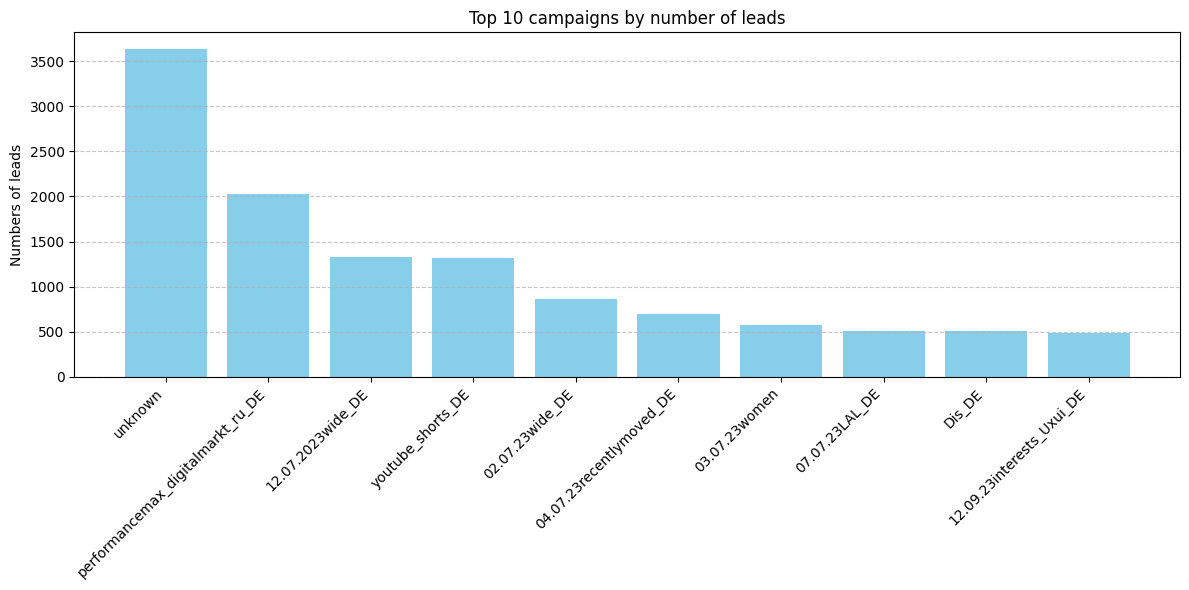

,Campaign,Leads,Clicks,Conversion_rate
133,unknown,3638,76602.0,0.047492
116,performancemax_digitalmarkt_ru_DE,2022,NaN,NaN
18,12.07.2023wide_DE,1326,22768.0,0.058240
151,youtube_shorts_DE,1312,57873.0,0.022670
2,02.07.23wide_DE,866,10281.0,0.084233
5,04.07.23recentlymoved_DE,698,7611.0,0.091709
4,03.07.23women,577,7139.0,0.080824
8,07.07.23LAL_DE,512,5813.0,0.088078
60,Dis_DE,504,NaN,NaN
19,12.09.23interests_Uxui_DE,487,6301.0,0.077289


In [145]:
# Сортируем кампании по количеству лидов и выбираем топ-10
top10_leads = campaign_performance.sort_values(by='Leads', ascending=False).head(10)

# Визуализация
plt.figure(figsize=(12,6))
plt.bar(top10_leads['Campaign'], top10_leads['Leads'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numbers of leads')
plt.title('Top 10 campaigns by number of leads')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Показываем таблицу
top10_leads


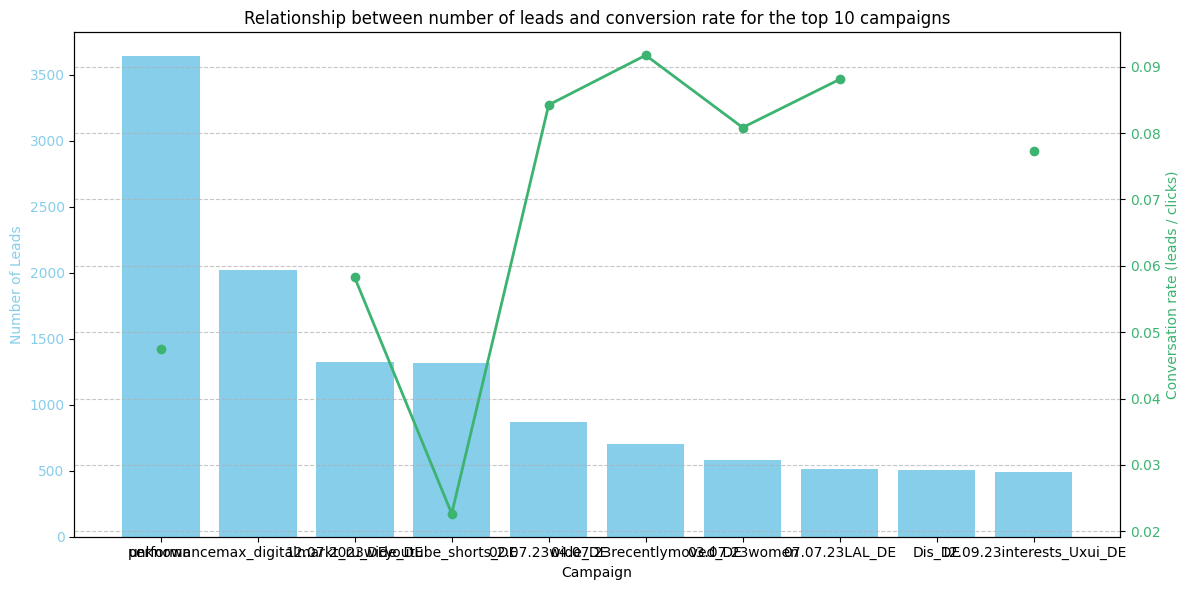

In [146]:

# Берём топ-10 кампаний по количеству лидов
top10_combined = campaign_performance.sort_values(by='Leads', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12,6))

# 🔹 Столбики — количество лидов
ax1.bar(top10_combined['Campaign'], top10_combined['Leads'], color='skyblue', label='Number of leads')
ax1.set_xlabel('Campaign')
ax1.set_ylabel('Number of Leads', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# 🔸 Линия — коэффициент конверсии
ax2 = ax1.twinx()
ax2.plot(top10_combined['Campaign'], top10_combined['Conversion_rate'], color='mediumseagreen', marker='o', linewidth=2, label='Conversation rate')
ax2.set_ylabel('Conversation rate (leads / clicks)', color='mediumseagreen')
ax2.tick_params(axis='y', labelcolor='mediumseagreen')

plt.title('Relationship between number of leads and conversion rate for the top 10 campaigns')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


- Leaders by conversion rate:

Campaigns bbo_DE (0.91), blog2_DE (0.86), and web2408_DE (0.81) show the highest conversion rates —
meaning almost every second or third click turns into a lead.

- Balance between clicks and leads:

For example, 24.09.23retargeting_DE has many clicks (4143), but a conversion rate of only 0.11% —
this means the traffic is cheap but low quality.

In contrast, bbo_DE shows high conversion with a moderate number of clicks — a sign of an effective and well-targeted campaign.

- Leaders by number of leads:

Campaign: unknown

Generated 3643 leads — the highest among all campaigns.

However, the conversion rate is low (~3.3%), which indicates low traffic quality (possibly ads were shown to an irrelevant audience).

performancemax_digitalmarkt_ru_DE has a large number of leads but no clicks. This may indicate offline attribution — users may have seen the ad but converted later directly via website, phone, or registration without clicking the ad.
Such users may not be linked to clicks in the system.

-

In [147]:
# Количество лидов по источникам
leads_per_source = (
    Deals_clean.groupby('Source')['Contact Name']
    .nunique()
    .reset_index(name='Leads')
)

# Успешные сделки (выигранные статусы)
won_stages = ['Payment Done', 'Free Education']

wins_per_source = (
    Deals_clean.groupby('Source')['Stage']
    .apply(lambda x: x.isin(won_stages).sum())
    .reset_index(name='Wins')
)

# Объединяем всё
source_summary = pd.merge(leads_per_source, wins_per_source, on='Source', how='left')

# Считаем коэффициент конверсии
source_summary['Conversion_rate'] = (
    source_summary['Wins'] / source_summary['Leads'] * 100
).round(2)

# Убираем источники без лидов (если есть пустые строки)
source_summary = source_summary.dropna(subset=['Leads'])

#  Сортируем по количеству лидов и по конверсии
top10_leads = source_summary.sort_values(by='Leads', ascending=False).head(10)
top10_conversion = source_summary.sort_values(by='Conversion_rate', ascending=False).head(10)

source_summary.head(10)


,Source,Leads,Wins,Conversion_rate
0,Bloggers,780,167,21.41
1,CRM,1311,84,6.41
2,Facebook Ads,3370,862,25.58
3,Google Ads,3075,640,20.81
4,Offline,2,1,50.00
5,Organic,2041,442,21.66
6,Partnership,125,6,4.80
7,SMM,1380,316,22.90
8,Telegram posts,816,162,19.85
9,Test,132,20,15.15


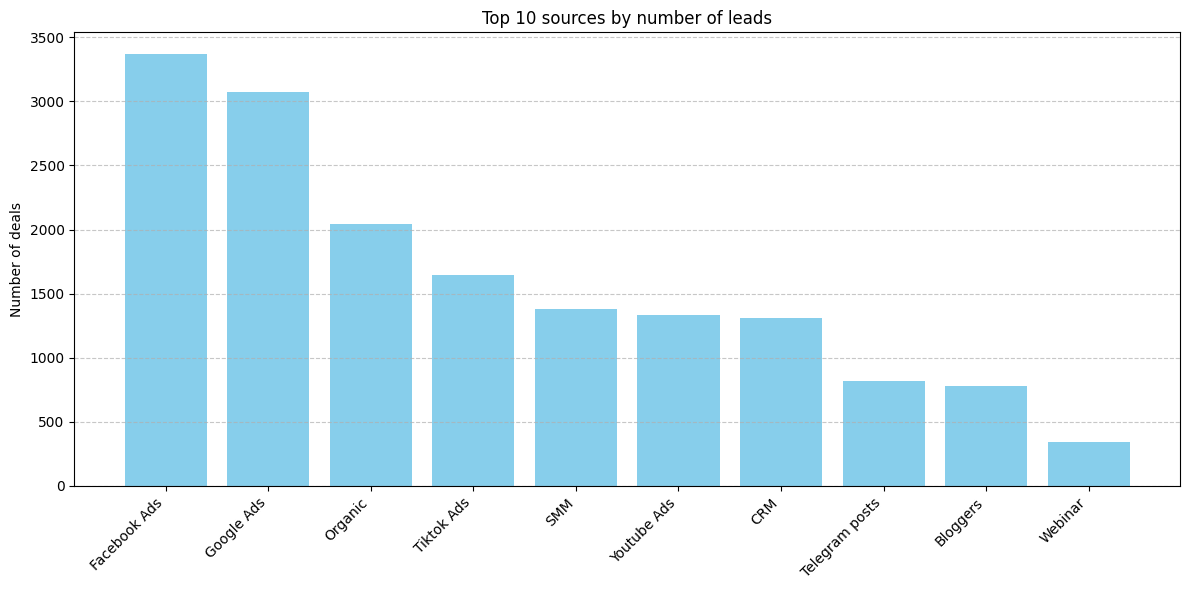

In [148]:
plt.figure(figsize=(12,6))
plt.bar(top10_leads['Source'], top10_leads['Leads'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of deals')
plt.title('Top 10 sources by number of leads')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

By number of leads (Leads):

The top sources by lead volume are Facebook Ads (3373), Google Ads (3078), and Organic (2046).

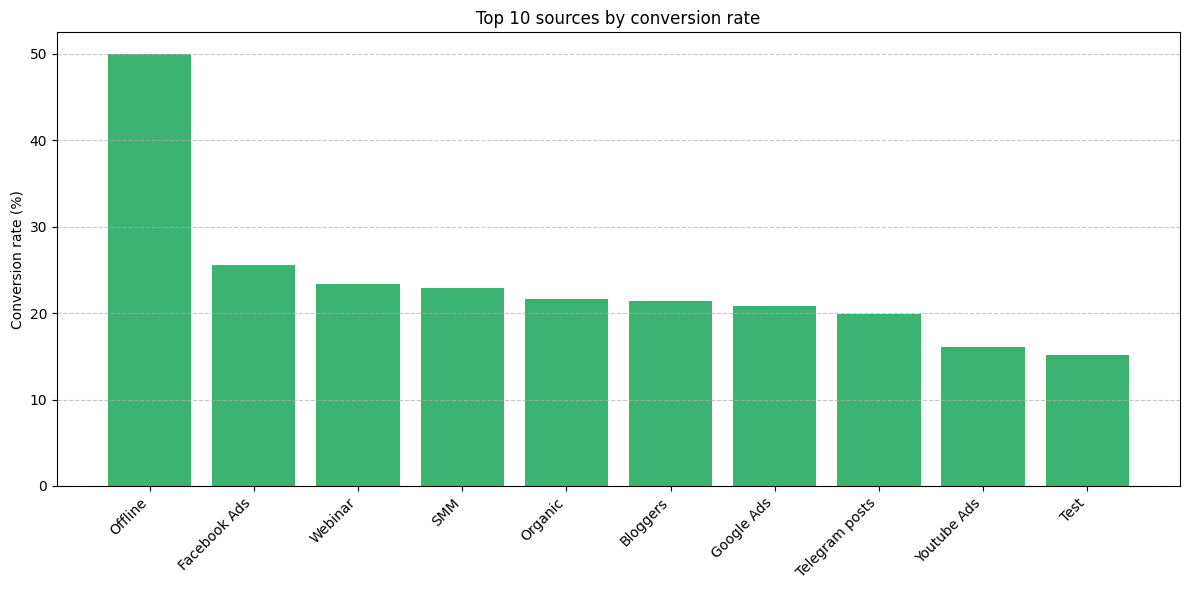

In [149]:
plt.figure(figsize=(12,6))
plt.bar(top10_conversion['Source'], top10_conversion['Conversion_rate'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Conversion rate (%)')
plt.title('Top 10 sources by conversion rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

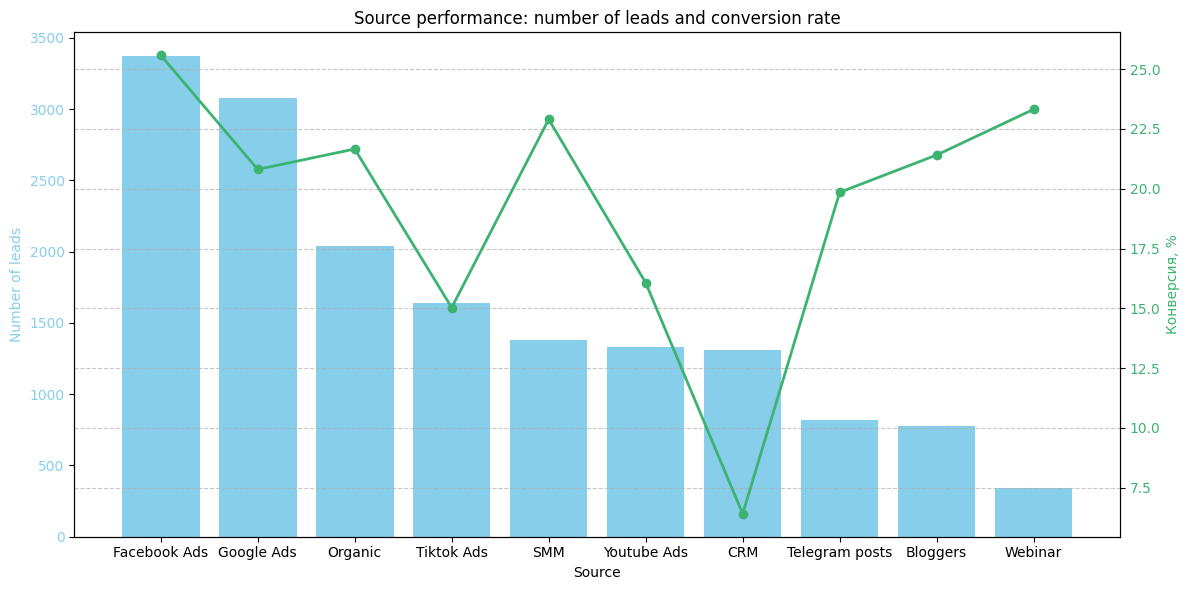

In [150]:

# Берём топ-10 источников по количеству лидов
top10_sources = source_summary.sort_values(by='Leads', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12,6))

# 🔹 Столбики — количество лидов
ax1.bar(top10_sources['Source'], top10_sources['Leads'], color='skyblue', label='Number of deals')
ax1.set_xlabel('Source')
ax1.set_ylabel('Number of leads', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# 🔸 Линия — коэффициент конверсии (%)
ax2 = ax1.twinx()
ax2.plot(top10_sources['Source'], top10_sources['Conversion_rate'], color='mediumseagreen', marker='o', linewidth=2, label='Конверсия, %')
ax2.set_ylabel('Конверсия, %', color='mediumseagreen')
ax2.tick_params(axis='y', labelcolor='mediumseagreen')

plt.title('Source performance: number of leads and conversion rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


By conversion rate (Conversion_rate):

The highest conversion rates are seen in Webinar (7.87), Organic (7.14%), and SMM (6.59%) — indicating high-quality leads, with most of them converting into successful deals.

-


Sales department performance analysis:

1. Evaluate the effectiveness of individual deal owners and advertising campaigns in terms of the number of processed deals, conversion rate, and total sales revenue.

In [151]:
# Определяем выигрышные стадии
won_stages = ['payment done']

# Группировка по менеджерам
sales_by_owner = (
    Deals_clean.groupby('Deal Owner Name')
    .agg(
        leads=('Contact Name', 'nunique'),  # уникальные лиды
        wins=('Stage', lambda x: x.str.lower().isin(won_stages).sum()),
        total_sales=('Initial Amount Paid', 'sum')
    )
    .reset_index()
)

# Расчёт конверсии
sales_by_owner['conversion_rate'] = (
    sales_by_owner['wins'] / sales_by_owner['leads'] * 100
)

# Сортировка по конверсии
sales_by_owner = sales_by_owner.sort_values(by='conversion_rate', ascending=False)

sales_by_owner.head(10)


,Deal Owner Name,leads,wins,total_sales,conversion_rate
16,Oliver Taylor,151,153,152650,101.324503
21,Ulysses Adams,1629,564,540050,34.622468
22,Victor Barnes,927,237,343100,25.566343
12,Julia Nelson,1544,388,382961,25.129534
11,John Doe,8,2,3600,25.000000
15,Nina Scott,917,216,206150,23.555071
17,Paula Underwood,1404,325,325750,23.148148
2,Ben Hall,1050,241,241700,22.952381
5,Charlie Davis,2021,429,440400,21.227115
13,Kevin Parker,421,86,68650,20.427553


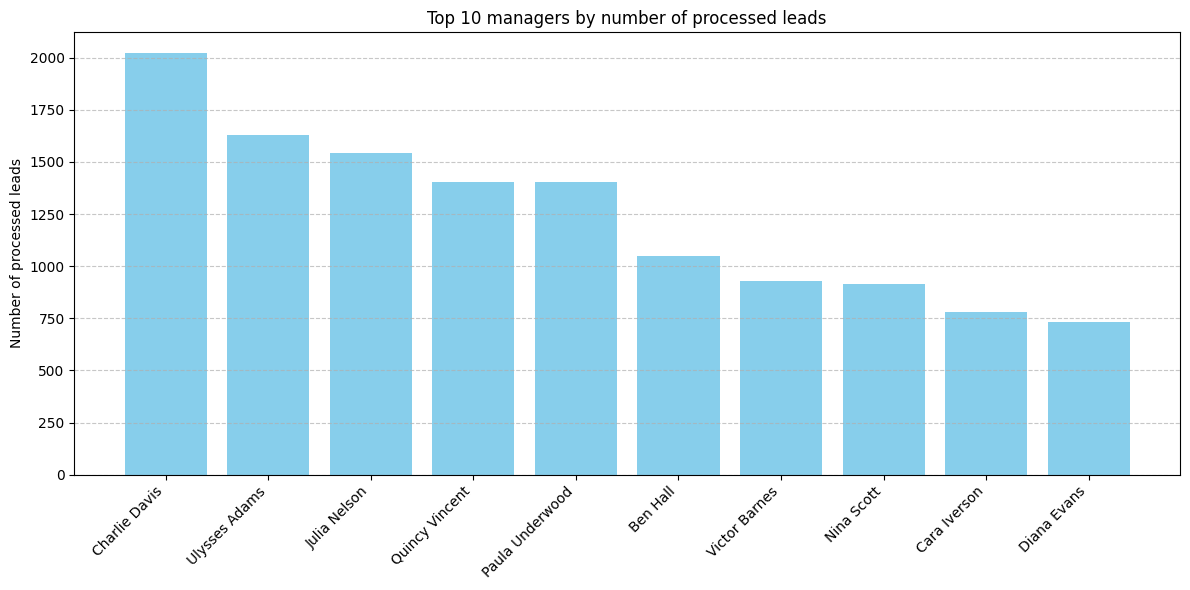

In [152]:
# Топ-10 менеджеров по количеству уникальных лидов
top10_leads = sales_by_owner.sort_values(by='leads', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_leads['Deal Owner Name'], top10_leads['leads'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of processed leads')
plt.title('Top 10 managers by number of processed leads')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

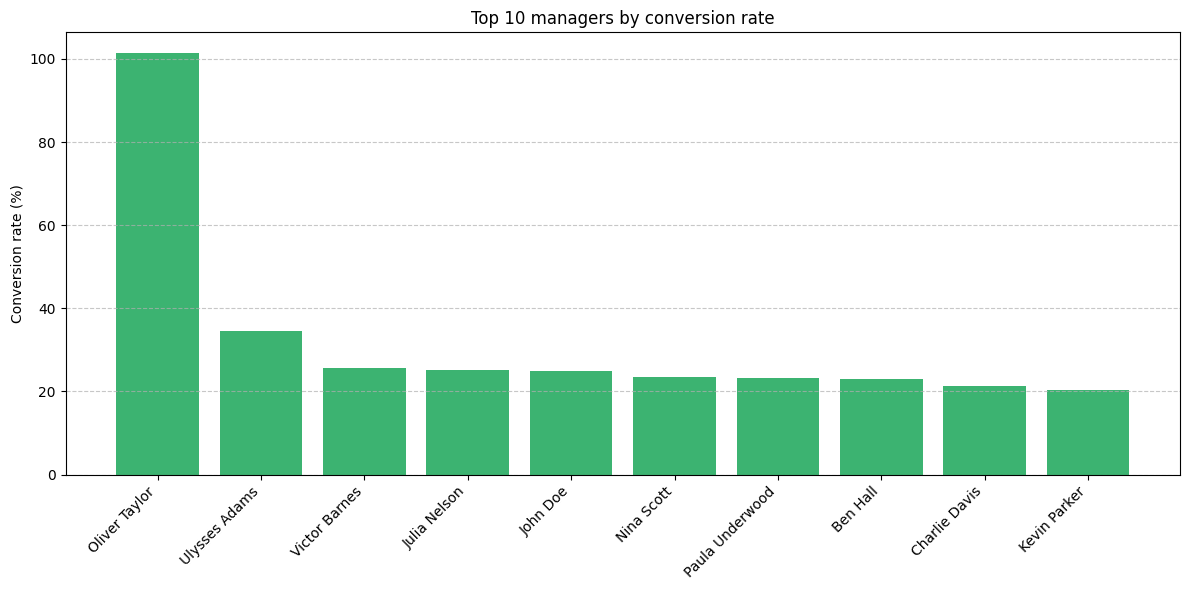

In [153]:
# Топ-10 менеджеров по коэффициенту конверсии
top10_conversion = sales_by_owner.sort_values(by='conversion_rate', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_conversion['Deal Owner Name'], top10_conversion['conversion_rate'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Conversion rate (%)')
plt.title('Top 10 managers by conversion rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

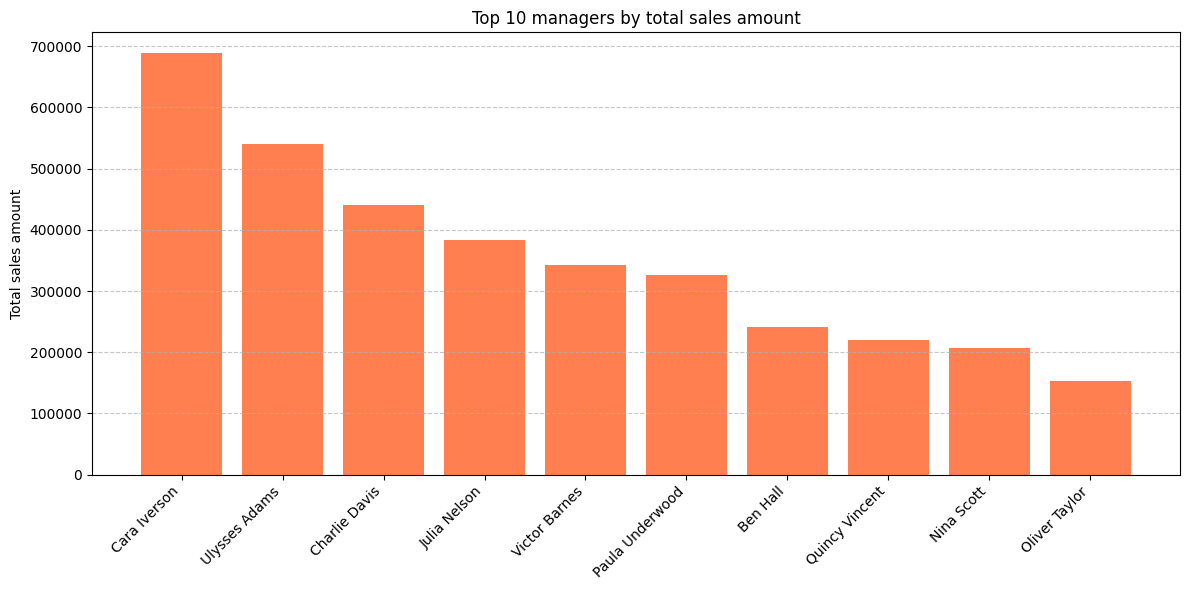

In [154]:
# Топ-10 менеджеров по общей сумме продаж
top10_sales = sales_by_owner.sort_values(by='total_sales', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_sales['Deal Owner Name'], top10_sales['total_sales'], color='coral')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total sales amount')
plt.title('Top 10 managers by total sales amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

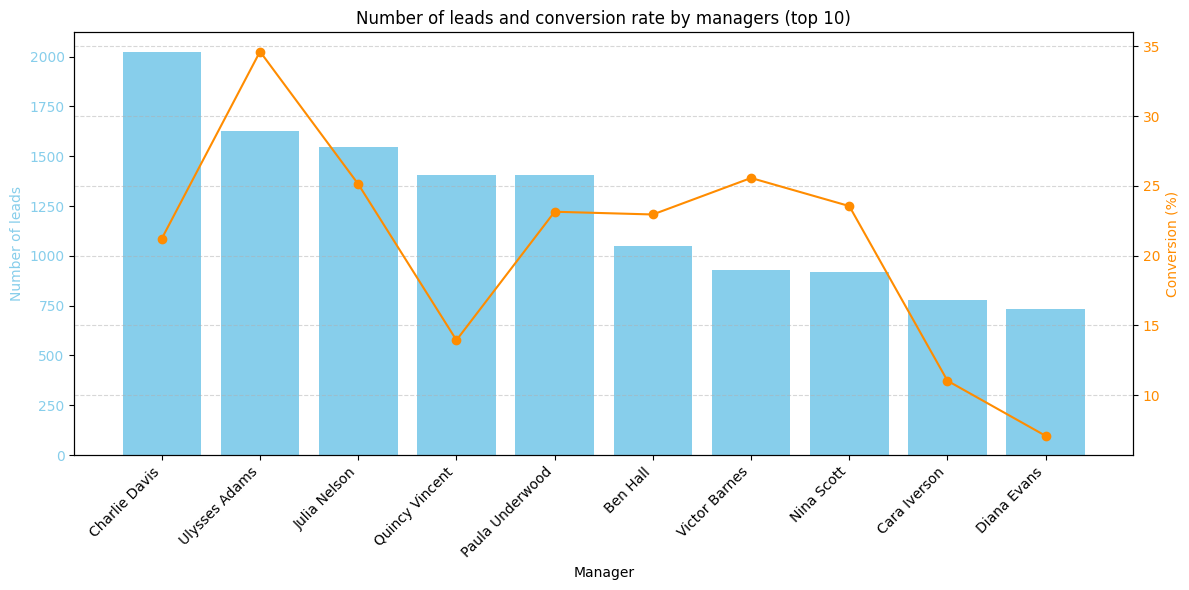

,Deal Owner Name,leads,wins,total_sales,conversion_rate
5,Charlie Davis,2021,429,440400,21.227115
21,Ulysses Adams,1629,564,540050,34.622468
12,Julia Nelson,1544,388,382961,25.129534
18,Quincy Vincent,1405,196,219601,13.950178
17,Paula Underwood,1404,325,325750,23.148148
2,Ben Hall,1050,241,241700,22.952381
22,Victor Barnes,927,237,343100,25.566343
15,Nina Scott,917,216,206150,23.555071
4,Cara Iverson,779,86,688400,11.039795
6,Diana Evans,733,52,50450,7.094134


In [155]:
import matplotlib.pyplot as plt

#  Берём топ-10 менеджеров по лидам
top10 = sales_by_owner.sort_values(by='leads', ascending=False).head(10)

# Создаём график
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы — количество лидов
ax1.bar(top10['Deal Owner Name'], top10['leads'], color='skyblue', label='Количество лидов')
ax1.set_xlabel('Manager')
ax1.set_ylabel('Number of leads', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')


plt.xticks(rotation=45, ha='right')

# Вторая ось — конверсия
ax2 = ax1.twinx()
ax2.plot(top10['Deal Owner Name'], top10['conversion_rate'], color='darkorange', marker='o', label='Conversion (%)')
ax2.set_ylabel('Conversion (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Заголовок и оформление
plt.title('Number of leads and conversion rate by managers (top 10)')
fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

top10

In [156]:
# Группируем сделки
deals_summary = (
    Deals_clean.groupby('Campaign')
    .agg(
        leads=('Contact Name', 'nunique'),
        wins=('Stage', lambda x: x.str.lower().eq('payment done').sum()),
        total_sales=('Initial Amount Paid', 'sum')
    )
    .reset_index()
)

# Группируем расходы
spend_summary = (
    Spend_clean.groupby('Campaign')
    .agg(spend=('Spend', 'sum'))
    .reset_index()
)

# Объединяем таблицы (outer join — все кампании)
campaigns_merged = pd.merge(spend_summary, deals_summary, on='Campaign', how='outer')

# Заполняем пустые значения
campaigns_merged[['leads', 'wins', 'total_sales', 'spend']] = campaigns_merged[
    ['leads', 'wins', 'total_sales', 'spend']
].fillna(0)

# Конверсия
campaigns_merged['conversion_rate'] = (
    campaigns_merged['wins'] / campaigns_merged['leads'].replace(0, pd.NA) * 100
).fillna(0).round(2)

campaigns_merged.head(10)


/tmp/ipykernel_1609/3827404866.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0).round(2)


,Campaign,spend,leads,wins,total_sales,conversion_rate
0,01.02.24wide_webinar_DE,189.91,0.0,0.0,0.0,0.00
1,01.04.23women_PL,357.25,30.0,0.0,0.0,0.00
2,02.05.24test_DE,164.04,96.0,7.0,27000.0,7.29
3,02.07.23wide_DE,6913.60,866.0,181.0,193950.0,20.90
4,02.08.23interests_DE,69.30,8.0,0.0,0.0,0.00
5,03.07.23women,4219.75,577.0,117.0,119550.0,20.28
6,04.07.23recentlymoved_DE,4523.31,698.0,125.0,143100.0,17.91
7,05.07.23interests_DE,333.73,33.0,6.0,6000.0,18.18
8,05.09.2023wide_DE,244.51,6.0,2.0,1500.0,33.33
9,07.07.23LAL_DE,4200.37,512.0,111.0,126800.0,21.68


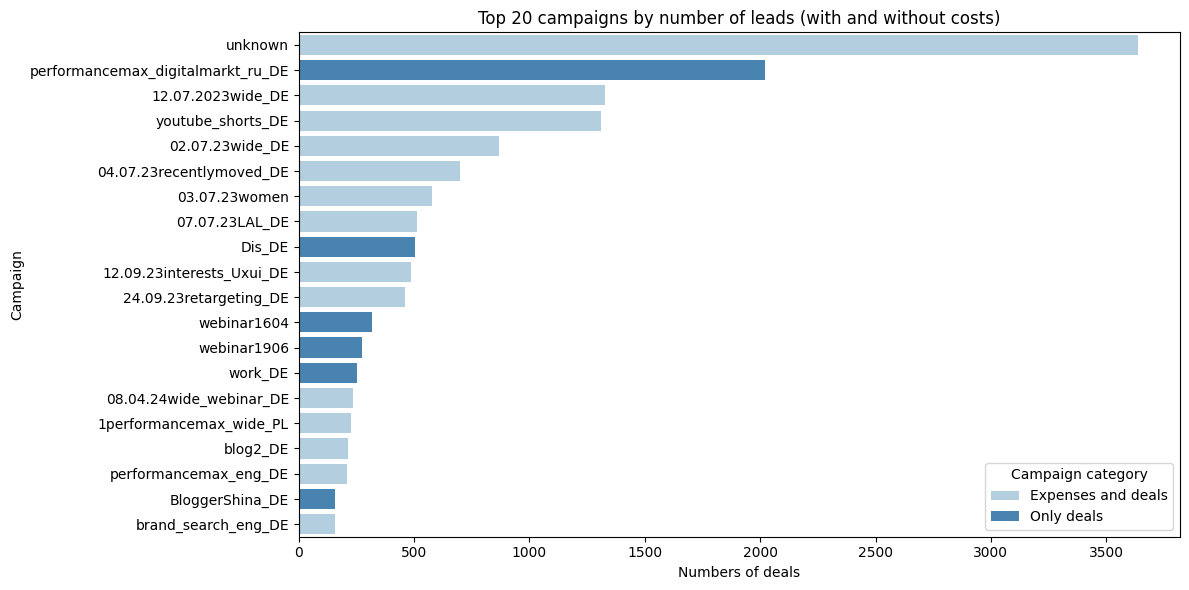

In [157]:
# Две категории: есть расходы и сделки / нет расходов, но сделки есть
def classify_campaign_simple(row):
    if row['spend'] > 0 and row['leads'] > 0:
        return 'Expenses and deals'
    elif row['spend'] == 0 and row['leads'] > 0:
        return 'Only deals'
    else:
        return None  # остальные не учитываем

campaigns_2cat = campaigns_merged.copy()
campaigns_2cat['category'] = campaigns_2cat.apply(classify_campaign_simple, axis=1)

# Фильтруем только кампании, попавшие в эти две категории
filtered = campaigns_2cat[campaigns_2cat['category'].notna()]

# Сравниваем количество лидов
plt.figure(figsize=(12,6))
sns.barplot(data=filtered.sort_values(by='leads', ascending=False).head(20),
            x='leads', y='Campaign', hue='category', dodge=False, palette='Blues')
plt.title('Top 20 campaigns by number of leads (with and without costs)')
plt.xlabel('Numbers of deals')
plt.ylabel('Campaign')
plt.legend(title='Campaign category')
plt.tight_layout()
plt.show()


In [158]:
#Категории кампаний
def classify_campaign(row):
    if row['spend'] > 0 and row['leads'] > 0:
        return 'Expenses and deals'
    elif row['spend'] > 0 and row['leads'] == 0:
        return 'Expenses only'
    elif row['spend'] == 0 and row['leads'] > 0:
        return 'Deals only'
    else:
        return '— No data available'

campaigns_merged['category'] = campaigns_merged.apply(classify_campaign, axis=1)

/tmp/ipykernel_1609/1414900670.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=campaigns_by_result, x='category', y='spend', palette='Blues')


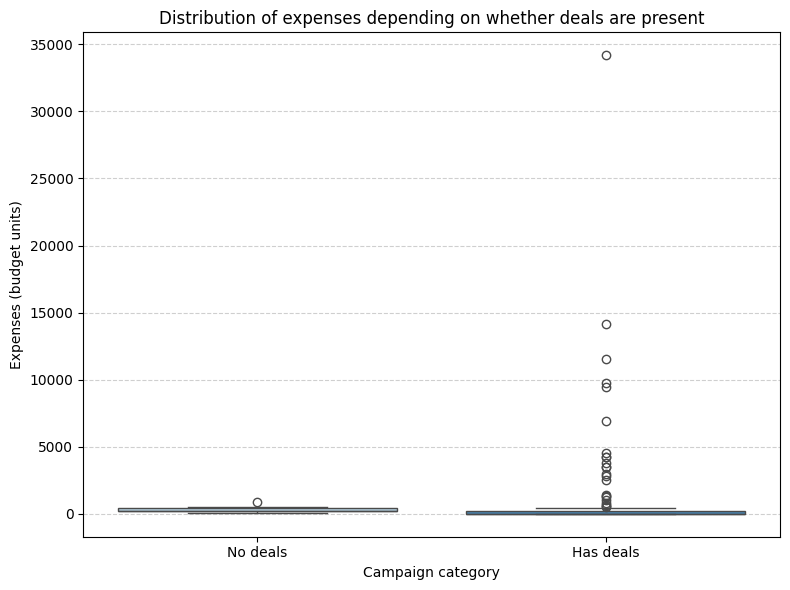

In [159]:
def classify_by_result(row):
    if row['leads'] > 0:
        return 'Has deals'
    elif row['leads'] == 0:
        return 'No deals'
    else:
        return None

campaigns_by_result = campaigns_merged.copy()
campaigns_by_result['category'] = campaigns_by_result.apply(classify_by_result, axis=1)

plt.figure(figsize=(8,6))
sns.boxplot(data=campaigns_by_result, x='category', y='spend', palette='Blues')
plt.title('Distribution of expenses depending on whether deals are present')
plt.xlabel('Campaign category')
plt.ylabel('Expenses (budget units)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



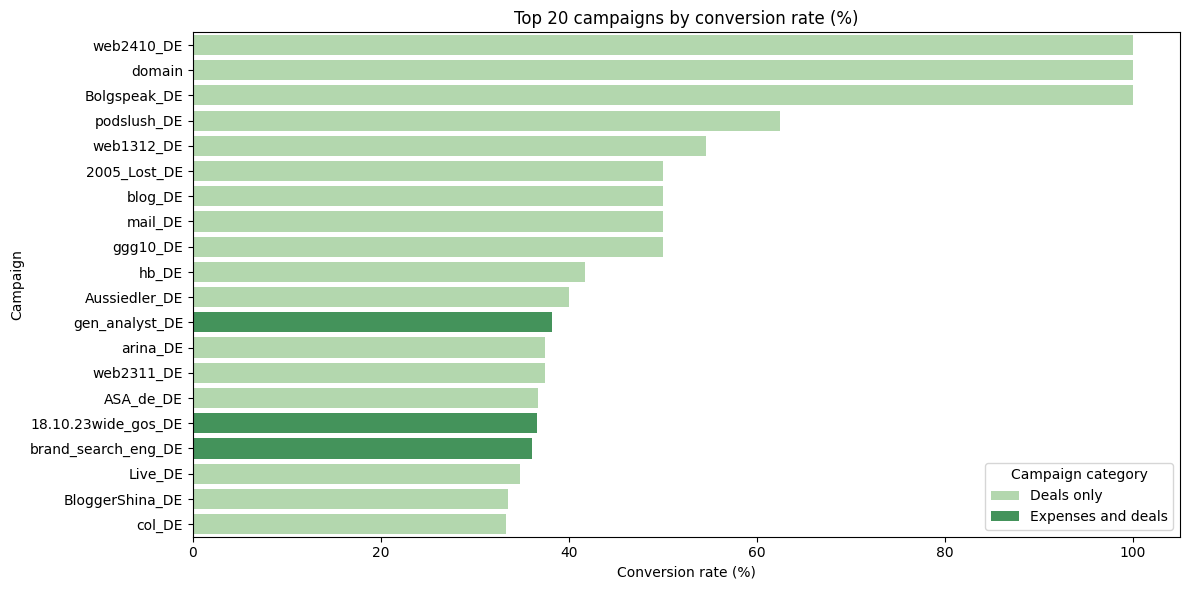

,Campaign,spend,leads,wins,total_sales,conversion_rate,category
146,web2410_DE,0.00,1.0,1.0,1000.0,100.00,Deals only
96,domain,0.00,1.0,1.0,5000.0,100.00,Deals only
64,Bolgspeak_DE,0.00,1.0,1.0,1000.0,100.00,Deals only
128,podslush_DE,0.00,8.0,5.0,5500.0,62.50,Deals only
142,web1312_DE,0.00,11.0,6.0,6000.0,54.55,Deals only
42,2005_Lost_DE,0.00,6.0,3.0,3000.0,50.00,Deals only
85,blog_DE,0.00,2.0,1.0,1000.0,50.00,Deals only
115,mail_DE,0.00,2.0,1.0,1000.0,50.00,Deals only
104,ggg10_DE,0.00,2.0,1.0,1000.0,50.00,Deals only
107,hb_DE,0.00,12.0,5.0,5000.0,41.67,Deals only


In [160]:
top20_conversion = campaigns_merged.sort_values(by='conversion_rate', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=top20_conversion, x='conversion_rate', y='Campaign', hue='category', dodge=False, palette='Greens')
plt.title('Top 20 campaigns by conversion rate (%)')
plt.xlabel('Conversion rate (%)')
plt.ylabel('Campaign')
plt.legend(title='Campaign category')
plt.tight_layout()
plt.show()

top20_conversion

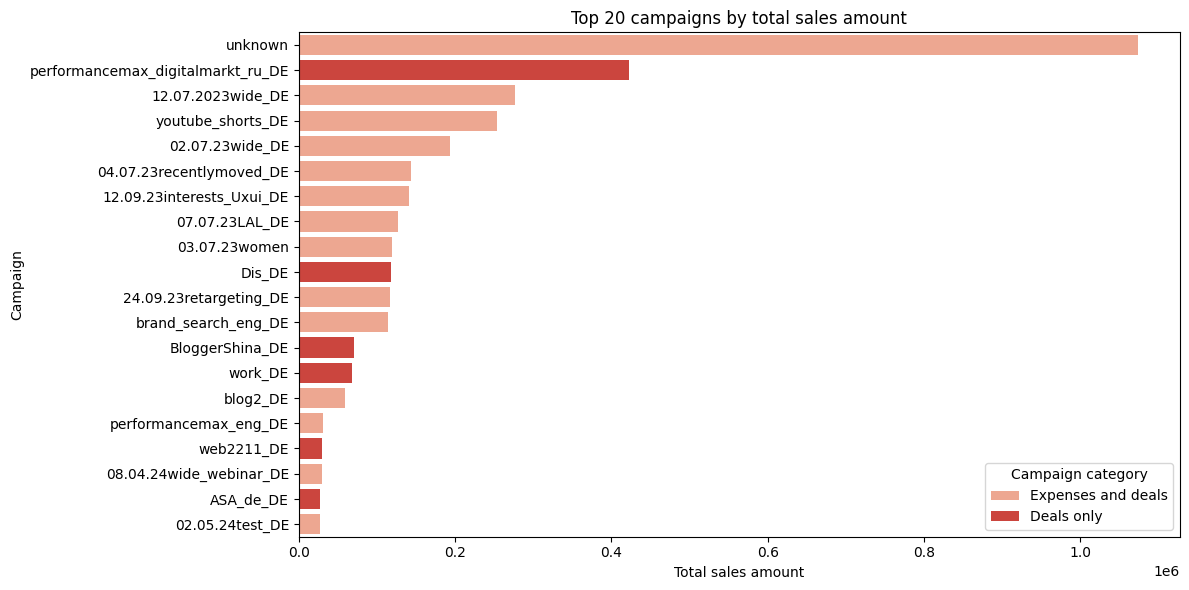

,Campaign,spend,leads,wins,total_sales,conversion_rate,category
139,unknown,11531.78,3638.0,891.0,1073811.0,24.49,Expenses and deals
122,performancemax_digitalmarkt_ru_DE,0.00,2022.0,372.0,422900.0,18.40,Deals only
20,12.07.2023wide_DE,9471.52,1326.0,223.0,277000.0,16.82,Expenses and deals
157,youtube_shorts_DE,14149.22,1312.0,215.0,253300.0,16.39,Expenses and deals
3,02.07.23wide_DE,6913.60,866.0,181.0,193950.0,20.90,Expenses and deals
6,04.07.23recentlymoved_DE,4523.31,698.0,125.0,143100.0,17.91,Expenses and deals
21,12.09.23interests_Uxui_DE,3753.06,487.0,131.0,140450.0,26.90,Expenses and deals
9,07.07.23LAL_DE,4200.37,512.0,111.0,126800.0,21.68,Expenses and deals
5,03.07.23women,4219.75,577.0,117.0,119550.0,20.28,Expenses and deals
66,Dis_DE,0.00,504.0,131.0,117950.0,25.99,Deals only


In [161]:
top20_sales = campaigns_merged.sort_values(by='total_sales', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=top20_sales, x='total_sales', y='Campaign', hue='category', dodge=False, palette='Reds')
plt.title('Top 20 campaigns by total sales amount')
plt.xlabel('Total sales amount')
plt.ylabel('Campaign')
plt.legend(title='Campaign category')
plt.tight_layout()
plt.show()

top20_sales

Низкие затраты при высокой конверсии и сумме продаж. Особенно выделяются:

interests_Uxui_DE,

brand_search_eng_DE,

02.07.23wide_DE.

-

Payment and product analysis:

1. Examine the distribution of payment types and their impact on deal success.


In [162]:
# Определяем успешные стадии
won_stages = ['Payment Done']

# Добавляем колонку "Success" для удобства анализа
Deals_clean['Success'] = Deals_clean['Stage'].str.lower().isin([s.lower() for s in won_stages])

In [163]:
# Считаем количество сделок по типу оплаты
pay_distribution = Deals_clean.groupby('Payment Type').agg(
    total_deals=('Id', 'count'),
    successful_deals=('Success', 'sum')
).reset_index()

# Считаем коэффициент конверсии по типу оплаты
pay_distribution['conversion_rate'] = (
    pay_distribution['successful_deals'] / pay_distribution['total_deals'] * 100
).round(2)

pay_distribution.sort_values(by='total_deals', ascending=False)


,Payment Type,total_deals,successful_deals,conversion_rate
3,no payment,18244,22,0.12
1,Partial Pay,3096,3096,100.00
0,One Payment,130,123,94.62
2,Recurring Payments,7,0,0.00


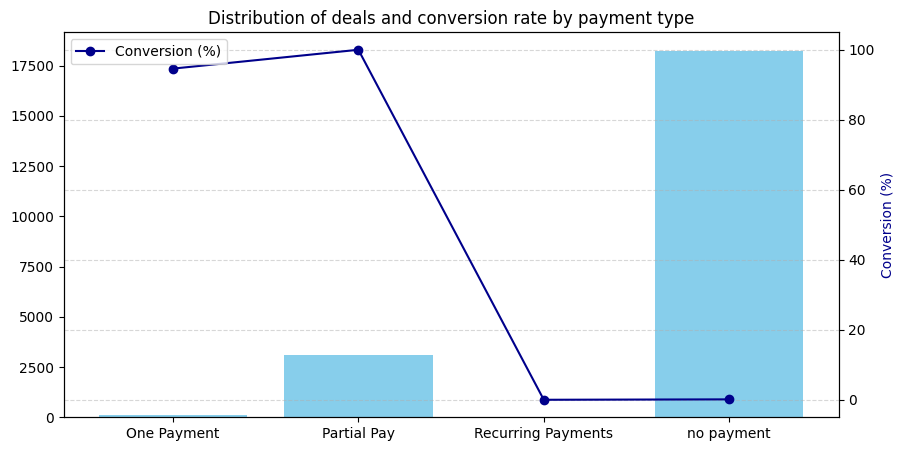

In [164]:
plt.figure(figsize=(10,5))

# Столбцы — общее количество сделок
plt.bar(pay_distribution['Payment Type'], pay_distribution['total_deals'], color='skyblue', label='Всего сделок')

# Линия — конверсия
plt.twinx()
plt.plot(pay_distribution['Payment Type'], pay_distribution['conversion_rate'], color='darkblue', marker='o', label='Conversion (%)')

plt.title('Distribution of deals and conversion rate by payment type')
plt.ylabel('Conversion (%)', color='darkblue')
plt.xlabel('Payment type')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()


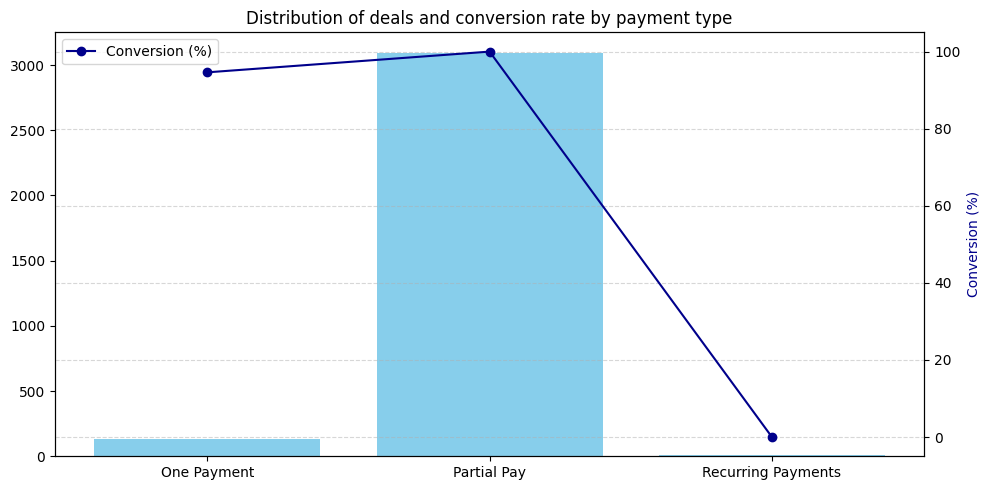

In [165]:
# Убираем тип оплаты "no payment"
pay_filtered = pay_distribution[pay_distribution['Payment Type'].str.lower() != 'no payment']

plt.figure(figsize=(10,5))

# Столбцы — общее количество сделок
plt.bar(pay_filtered['Payment Type'], pay_filtered['total_deals'],
        color='skyblue', label='Всего сделок')

# Линия — конверсия
plt.twinx()
plt.plot(pay_filtered['Payment Type'], pay_filtered['conversion_rate'],
         color='darkblue', marker='o', label='Conversion (%)')

plt.title('Distribution of deals and conversion rate by payment type')
plt.ylabel('Conversion (%)', color='darkblue')
plt.xlabel('Payment type')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


Recurring Payments — there are almost no deals (4), and none of them were successful.

Conclusion: this payment type is practically not used in this dataset, or deals using it are not being closed.

no payment — deals without payment (active deals in the consultation stage or deals that have not yet reached payment).

The most popular payment types are One Payment (100% conversion) or Partial Pay (94.66).

Analyze the popularity and success of different products and types of training.

In [166]:
Deals_clean['Product'].unique()

array(['No Cours', 'Web Developer', 'Digital Marketing', 'UX/UI Design',
       'Find yourself in IT', 'Data Analytics'], dtype=object)

In [167]:
Deals_clean['Education Type'].unique()

array(['No Cours', 'Morning', 'Evening'], dtype=object)

In [168]:
# Успешные стадии
won_stages = ['payment done']

# Группировка по продуктам
product_summary = (
    Deals_clean.groupby('Product')
    .agg(
        total_deals=('Id', 'count'),
        successful_deals=('Stage', lambda x: x.str.lower().isin(won_stages).sum()))
    .reset_index())


In [169]:
# Рассчитаем коэффициент конверсии
product_summary['conversion_rate'] = (
    product_summary['successful_deals'] / product_summary['total_deals'] * 100
).round(2)

# Сортируем по успешности
product_summary = product_summary.sort_values(by='conversion_rate', ascending=False)
product_summary

,Product,total_deals,successful_deals,conversion_rate
1,Digital Marketing,1976,1798,90.99
5,Web Developer,570,518,90.88
4,UX/UI Design,1012,899,88.83
2,Find yourself in IT,4,1,25.00
3,No Cours,17914,25,0.14
0,Data Analytics,1,0,0.00


In [170]:
# Убираем "No Cours" несостоявшиеся сделки
filtered_products = product_summary[product_summary['Product'] != 'No Cours']

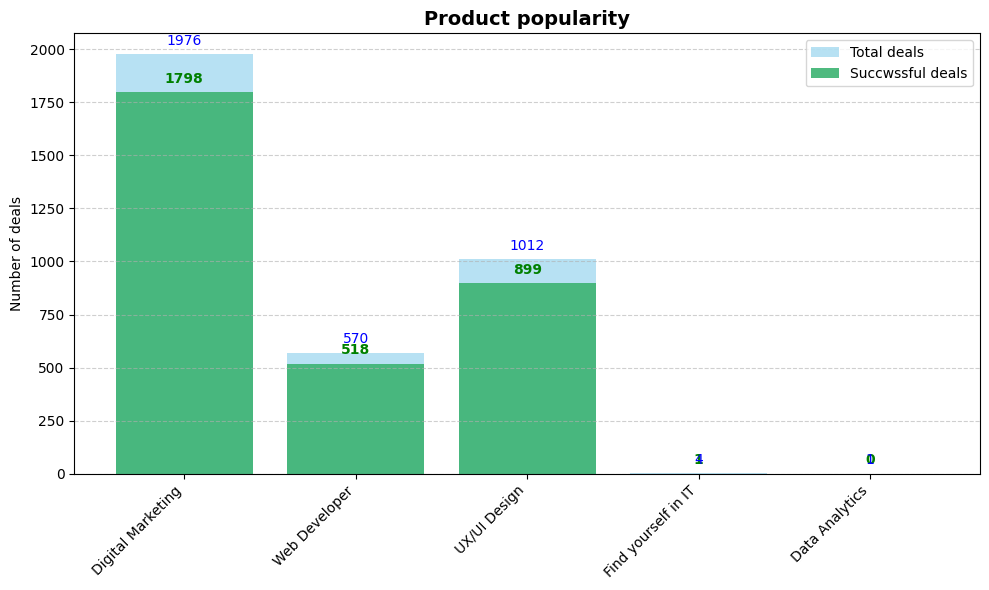

In [171]:
# Визуализация популярности продуктов
plt.figure(figsize=(10,6))
bars_total = plt.bar(filtered_products['Product'], filtered_products['total_deals'],
        label='Total deals', alpha=0.6, color='skyblue')
bars_success = plt.bar(filtered_products['Product'], filtered_products['successful_deals'],
        label='Succwssful deals', alpha=0.9, color='mediumseagreen')

for bar in bars_success:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, weight='bold', color='green')

for bar in bars_total:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, color='blue')

plt.title('Product popularity', fontsize=14, weight='bold')
plt.ylabel('Number of deals')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [172]:
import pandas as pd

# Преобразуем даты, если ещё не преобразованы
Deals_clean['Created Time'] = pd.to_datetime(Deals_clean['Created Time'], errors='coerce')
Deals_clean['Closing Date'] = pd.to_datetime(Deals_clean['Closing Date'], errors='coerce')

# Группировка по продукту
product_age = (
    Deals_clean.groupby('Product')
    .agg(
        first_deal=('Created Time', 'min'),
        last_deal=('Closing Date', 'max'),
    )
    .reset_index()
)

# Рассчитываем, как долго продукт «живёт» (в днях)
product_age['days_active'] = (product_age['last_deal'] - product_age['first_deal']).dt.days

# Сортируем по активности
product_age = product_age.sort_values(by='days_active', ascending=False)

product_age.head(10)


,Product,first_deal,last_deal,days_active
3,No Cours,2023-07-03 17:03:00,2024-12-11,526
1,Digital Marketing,2023-07-04 10:11:00,2024-09-25,448
5,Web Developer,2023-07-18 16:51:00,2024-06-21,338
4,UX/UI Design,2023-07-19 09:01:00,2024-06-20,336
2,Find yourself in IT,2023-11-17 17:20:00,2024-05-11,175
0,Data Analytics,2023-08-01 18:06:00,2023-08-01,-1


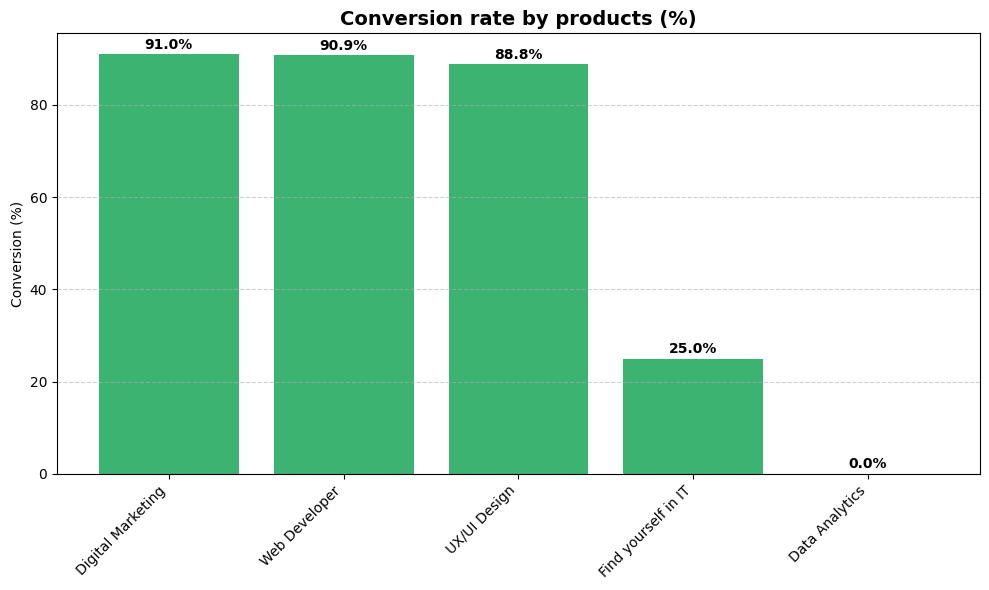

In [173]:
# Визуализация количество сделок и успешных продаж по продуктам
plt.figure(figsize=(10,6))
bars = plt.bar(filtered_products['Product'], filtered_products['conversion_rate'], color='mediumseagreen')

# Подписи над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold')

plt.title('Conversion rate by products (%)', fontsize=14, weight='bold')
plt.ylabel('Conversion (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [174]:
# Исключаем "No Cours"
filtered_edu = Deals_clean[Deals_clean['Education Type'] != 'No Cours']

# Группируем по Education Type
edu_summary = (
    filtered_edu.groupby('Education Type')
    .agg(
        total_deals=('Id', 'count'),
        successful_deals=('Stage', lambda x: (x.str.lower() == 'payment done').sum())
    )
    .reset_index()
)

# Расчёт конверсии
edu_summary['conversion_rate'] = edu_summary['successful_deals'] / edu_summary['total_deals'] * 100


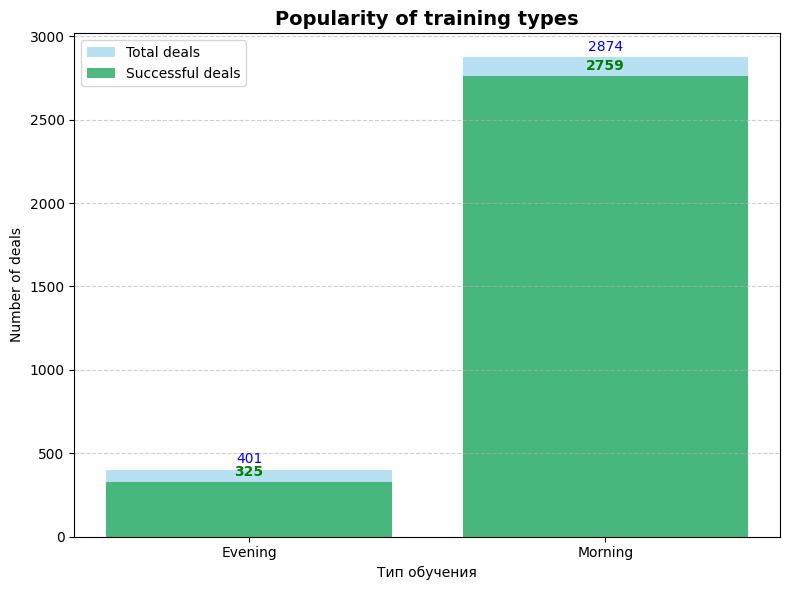

In [175]:
# Визуализация количества сделок
plt.figure(figsize=(8,6))
bars_total = plt.bar(edu_summary['Education Type'], edu_summary['total_deals'],
        label='Total deals', alpha=0.6, color='skyblue')
bars_success = plt.bar(edu_summary['Education Type'], edu_summary['successful_deals'],
        label='Successful deals', alpha=0.9, color='mediumseagreen')


for bar in bars_success:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, weight='bold', color='green')

for bar in bars_total:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, color='blue')

plt.title('Popularity of training types', fontsize=14, weight='bold')
plt.ylabel('Number of deals')
plt.xlabel('Тип обучения')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [176]:


# Убедимся, что даты в правильном формате
Deals_clean['Created Time'] = pd.to_datetime(Deals_clean['Created Time'], errors='coerce')
Deals_clean['Closing Date'] = pd.to_datetime(Deals_clean['Closing Date'], errors='coerce')

# Исключаем выбросы — когда дата закрытия раньше даты создания
Deals_filtered = Deals_clean[Deals_clean['Closing Date'] >= Deals_clean['Created Time']]

# Группировка по типу обучения
edu_age = (
    Deals_filtered.groupby('Education Type')
    .agg(
        first_deal=('Created Time', 'min'),
        last_deal=('Closing Date', 'max')
    )
    .reset_index()
)

# Считаем, сколько дней “живёт” каждый тип обучения
edu_age['days_active'] = (edu_age['last_deal'] - edu_age['first_deal']).dt.days

# Сортируем для наглядности
edu_age = edu_age.sort_values(by='days_active', ascending=False)

edu_age


,Education Type,first_deal,last_deal,days_active
2,No Cours,2023-07-03 20:17:00,2024-12-11,526
1,Morning,2023-07-05 18:06:00,2024-09-25,447
0,Evening,2023-07-19 11:55:00,2024-06-20,336


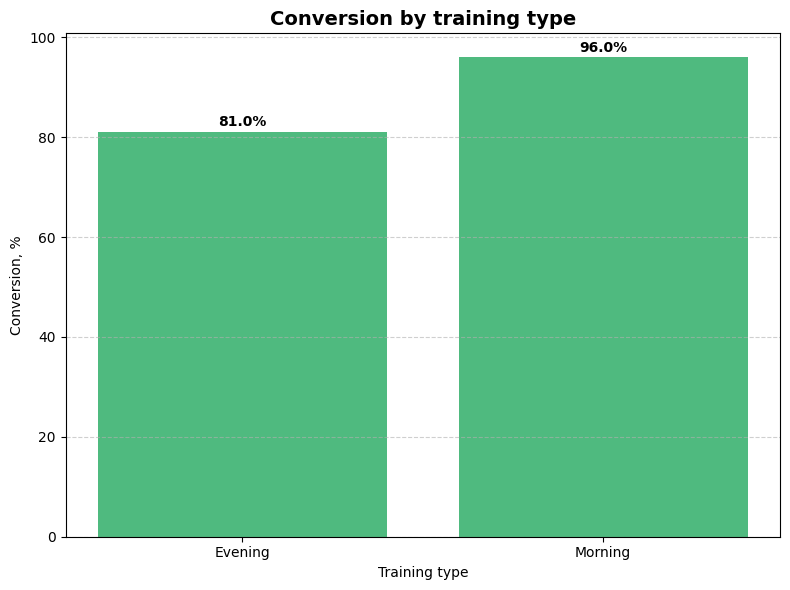

In [177]:
# Визуализация конверсии
plt.figure(figsize=(8,6))
bars = plt.bar(edu_summary['Education Type'], edu_summary['conversion_rate'], color='mediumseagreen', alpha=0.9)
plt.title('Conversion by training type', fontsize=14, weight='bold')
plt.ylabel('Conversion, %')
plt.xlabel('Training type')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Подписи с процентами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

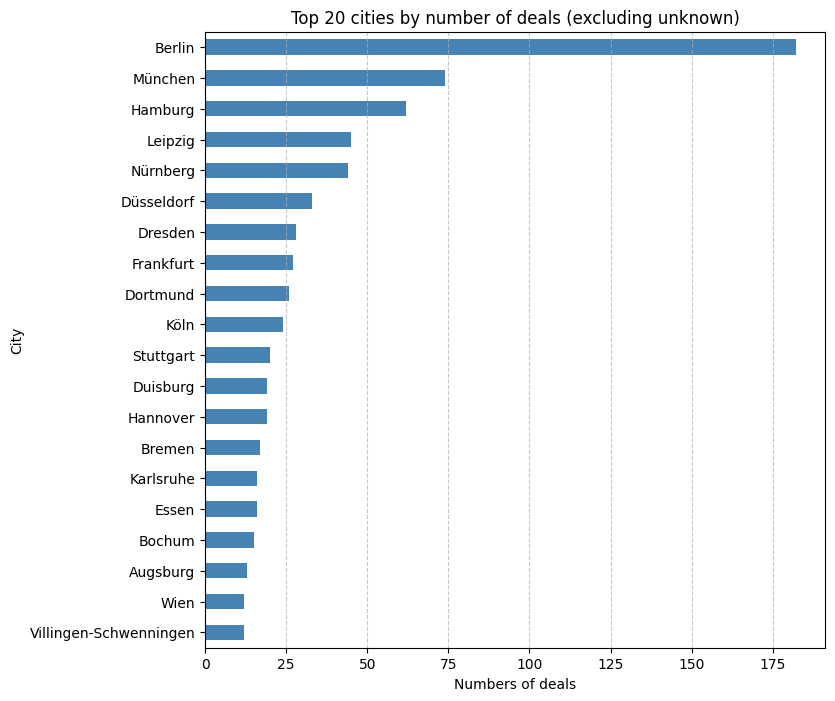

In [178]:
# Исключаем пустые и 'unknown' города
clean_cities = Deals_clean[
    Deals_clean['City'].notna() & (Deals_clean['City'].str.lower() != 'unknown')
]

# Считаем топ-20 городов по количеству сделок
top_cities = (
    clean_cities['City']
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

# Визуализация
plt.figure(figsize=(8, 8))
top_cities.plot(kind='barh', color='steelblue')
plt.title('Top 20 cities by number of deals (excluding unknown)')
plt.xlabel('Numbers of deals')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [179]:
lang_success = (
    Deals_clean.loc[Deals_clean['Stage'] == 'Payment Done']  # фильтруем только успешные сделки
    .groupby('Level of Deutsch')
    .size()  # считаем количество успешных сделок по каждому уровню
    / Deals_clean.groupby('Level of Deutsch').size()  # делим на общее количество сделок по уровню
)

lang_success = lang_success.sort_values(ascending=False)


/tmp/ipykernel_1609/1516156840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_success.index, y=lang_success.values, palette='coolwarm')


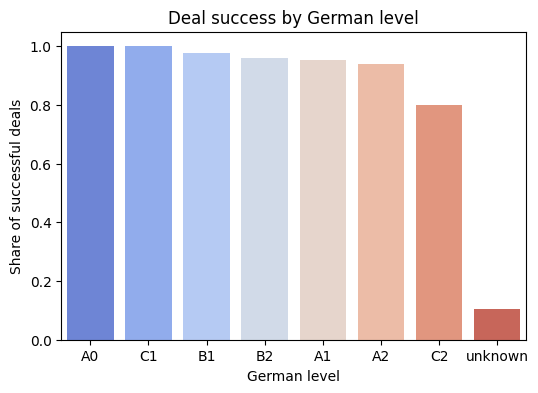

In [180]:
plt.figure(figsize=(6, 4))
sns.barplot(x=lang_success.index, y=lang_success.values, palette='coolwarm')

plt.title('Deal success by German level')
plt.xlabel('German level')
plt.ylabel('Share of successful deals')
plt.show()

Product analytics task
1. Calculate unit economics by product.


In [181]:

unit = pd.DataFrame()

unit['UA'] = [Deals_clean['Contact Name'].nunique()]
unit['T'] = [Deals_clean.shape[0]]
unit['B'] = [Deals_clean[Deals_clean['Stage'] == 'Payment Done']['Contact Name'].nunique()]
unit['AOV'] = [Deals_clean['Offer Total Amount'].mean()]
unit['AC'] = [Spend_clean['Spend'].sum()]
unit['CAC'] = unit['AC'] / unit['B']
unit['C1'] = unit['B'] / unit['UA']
unit['APC'] = Deals_clean.groupby('Contact Name')['Id'].count().mean()

unit['Revenue'] = [Deals_clean['Offer Total Amount'].sum()]
unit['Unit Profit'] = unit['AOV'] - unit['CAC']

unit.round(2)




,UA,T,B,AOV,AC,CAC,C1,APC,Revenue,Unit Profit
0,8145,21477,2629,1380.09,133005.21,50.59,0.32,2.64,29640211,1329.5


In [182]:
product_unit = (
    Deals_clean.groupby('Product', as_index=False)
    .agg({
        'Id': 'count',
        'Offer Total Amount': 'sum',
        'Contact Name': pd.Series.nunique
    })
    .rename(columns={'Id': 'T', 'Offer Total Amount': 'Revenue', 'Contact Name': 'B'})
)

# добавляем AOV, CAC и Unit Profit
total_spend = Spend_clean['Spend'].sum()
total_UA = Contacts_clean['Id'].nunique()

product_unit['AOV'] = product_unit['Revenue'] / product_unit['T']
product_unit['AC'] = total_spend / product_unit['Product'].nunique()
product_unit['CAC'] = product_unit['AC'] / product_unit['B']
product_unit['C1'] = product_unit['B'] / total_UA
product_unit['Unit Profit'] = product_unit['AOV'] - product_unit['CAC']

product_unit.round(2)



,Product,T,Revenue,B,AOV,AC,CAC,C1,Unit Profit
0,Data Analytics,1,6000,1,6000.00,22167.54,22167.54,0.00,-16167.54
1,Digital Marketing,1976,17870209,1711,9043.63,22167.54,12.96,0.09,9030.67
2,Find yourself in IT,4,1,3,0.25,22167.54,7389.18,0.00,-7388.93
3,No Cours,17914,89501,7515,5.00,22167.54,2.95,0.41,2.05
4,UX/UI Design,1012,8805400,946,8700.99,22167.54,23.43,0.05,8677.56
5,Web Developer,570,2869100,538,5033.51,22167.54,41.20,0.03,4992.31
